# Stellar Classification Pipeline
This notebook will guide us through:
1. Data Acquisition
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training and Evaluation

In [1]:
import os
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Display plots inline
%matplotlib inline

## 1. Data Acquisition
First, we will ensure that our dataset is downloaded.

In [2]:
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)
csv_file = os.path.join(data_dir, 'Stars.csv')

if not os.path.exists(csv_file):
    print("Downloading Stars.csv...")
    url = "https://github.com/YBIFoundation/Dataset/raw/main/Stars.csv"
    urllib.request.urlretrieve(url, csv_file)
    print("Download complete.")
else:
    print("Stars.csv already exists.")

Stars.csv already exists.


## 2. Exploratory Data Analysis (EDA)
Let's load the data using pandas and inspect its structure.

In [3]:
df = pd.read_csv(csv_file)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (240, 8)


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M


We will now plot the correlation matrix for numerical features and the distribution of our target variable (`Star type`).

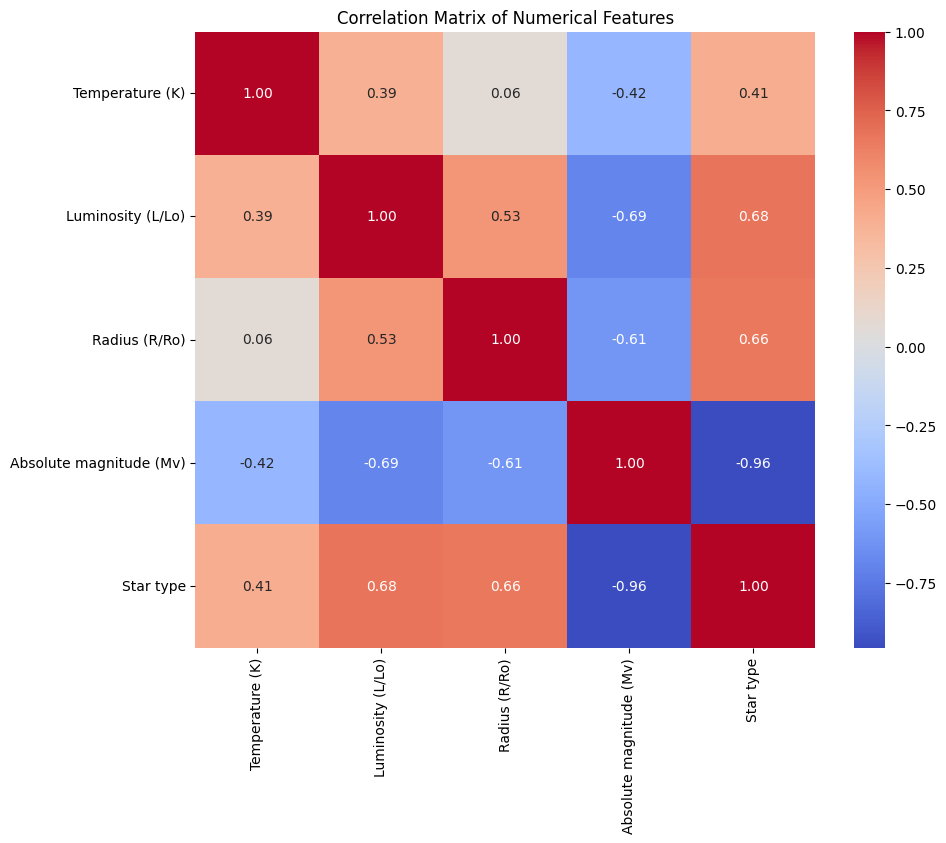

C:\Users\Malik\AppData\Local\Temp\ipykernel_2080\3933459320.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Star type', palette='viridis')


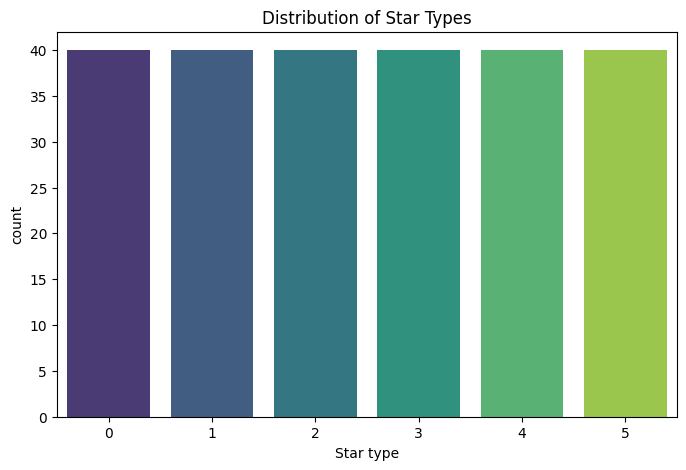

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Star type', palette='viridis')
plt.title('Distribution of Star Types')
plt.show()

## 3. Data Preprocessing
Machine learning models require features to be encoded and scaled appropriately. We will build a preprocessing pipeline to handle categorical and numerical columns separately.

In [5]:
X = df.drop(['Star type', 'Star category'], axis=1, errors='ignore')
y = df['Star type']

categorical_cols = ['Star color', 'Spectral Class']
numerical_cols = ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (192, 6)
Test set shape: (48, 6)


## 4. Model Training & Evaluation
We will train two robust models: **Random Forest** and **Support Vector Machine (SVM)**, then evaluate their performance using a classification report and a confusion matrix.

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



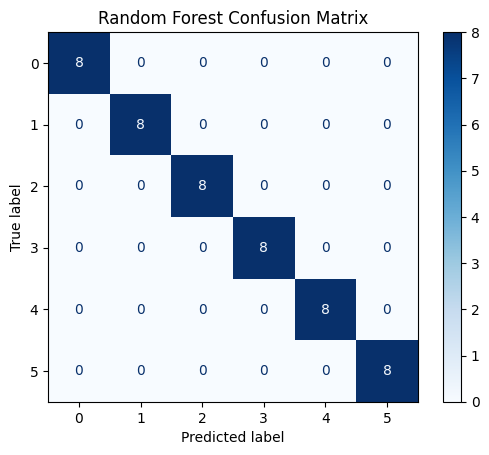

In [6]:
# Model 1: Random Forest
print("--- Random Forest ---")
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_test)

print(classification_report(y_test, rf_predictions))

cm_rf = confusion_matrix(y_test, rf_predictions)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()


--- Support Vector Machine (SVM) ---
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.75      0.86         8
           2       1.00      1.00      1.00         8
           3       0.89      1.00      0.94         8
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00         8

    accuracy                           0.94        48
   macro avg       0.95      0.94      0.94        48
weighted avg       0.95      0.94      0.94        48



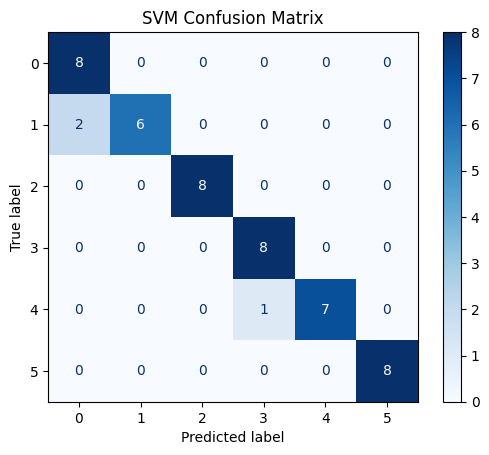

In [7]:
# Model 2: Support Vector Machine (SVM)
print("\n--- Support Vector Machine (SVM) ---")
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', SVC(random_state=42))])
svm_pipeline.fit(X_train, y_train)
svm_predictions = svm_pipeline.predict(X_test)

print(classification_report(y_test, svm_predictions))

cm_svm = confusion_matrix(y_test, svm_predictions)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

## 5. Accuracy Scores & Manual Testing
Let's explicitly print the accuracy scores and test the model with manual inputs.

In [8]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, rf_predictions)
svm_acc = accuracy_score(y_test, svm_predictions)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"SVM Accuracy: {svm_acc:.4f}")

Random Forest Accuracy: 1.0000
SVM Accuracy: 0.9375


### Manual Prediction
Enter the characteristics of a star below to classify it using the Random Forest model.

In [9]:
# Manual Inputs
temp = 3000       # Temperature (K)
lum = 0.002       # Luminosity (L/Lo)
rad = 0.15        # Radius (R/Ro)
abs_mag = 16.0    # Absolute magnitude (Mv)
color = 'Red'     # Star color
spectral = 'M'    # Spectral Class

# Create a DataFrame for the input
manual_input = pd.DataFrame({
    'Temperature (K)': [temp],
    'Luminosity (L/Lo)': [lum],
    'Radius (R/Ro)': [rad],
    'Absolute magnitude (Mv)': [abs_mag],
    'Star color': [color],
    'Spectral Class': [spectral]
})

# Predict using the trained Random Forest pipeline
prediction = rf_pipeline.predict(manual_input)[0]

star_types = {
    0: "Brown Dwarf",
    1: "Red Dwarf",
    2: "White Dwarf",
    3: "Main Sequence",
    4: "Supergiant",
    5: "Hypergiant"
}

print(f"Predicted Class: {prediction} -> {star_types.get(prediction, 'Unknown')}")

Predicted Class: 0 -> Brown Dwarf


In [10]:
import pickle


In [11]:
import pickle

# Save the preprocessor
with open('stars_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save the model
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_pipeline, f)

print("Saved successfully using Pickle!")

Saved successfully using Pickle!
